In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_excel('/content/drive/MyDrive/ML_Projects/Customerdefaultpred/Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [12]:
drop_cols = [
    "CustomerID",
    "Count",
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

df = df.drop(columns=drop_cols)


In [13]:
location_cols = [
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

df = df.drop(columns=location_cols)

In [14]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [15]:
df.isnull().sum()

,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0


In [16]:
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Building the pipeline

In [19]:
cat_features=X_train.select_dtypes(include=['object']).columns
num_features=X_train.select_dtypes(include=['int64','float64']).columns

In [22]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [25]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [26]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [31]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 47)
(1409, 47)


Model building

In [36]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(47,)),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dropout(0.2),

    Dense(1, activation='sigmoid')

])

In [37]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [38]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [39]:
history = model.fit(

    X_train_processed,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7604 - auc: 0.7750 - loss: 0.4825 - val_accuracy: 0.7870 - val_auc: 0.8270 - val_loss: 0.4442
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8014 - auc: 0.8401 - loss: 0.4252 - val_accuracy: 0.7941 - val_auc: 0.8322 - val_loss: 0.4312
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8019 - auc: 0.8437 - loss: 0.4208 - val_accuracy: 0.8012 - val_auc: 0.8371 - val_loss: 0.4255
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8063 - auc: 0.8526 - loss: 0.4099 - val_accuracy: 0.8004 - val_auc: 0.8381 - val_loss: 0.4262
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8067 - auc: 0.8553 - loss: 0.4055 - val_accuracy: 0.8012 - val_auc: 0.8379 - val_loss: 0.4264
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8161 - auc: 0.8570 - loss: 0.4055 - val_accuracy: 0.7977 - val_auc: 0.8388 - val_loss: 0.4234
Epoch 7/100
141/141 ━━━━━━━━━━━━━━

In [40]:
loss, accuracy, auc = model.evaluate(
    X_test_processed,
    y_test
)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - auc: 0.8463 - loss: 0.4155
Test Accuracy: 0.7984
Test AUC: 0.8463


In [41]:
y_prob = model.predict(X_test_processed)

y_pred = (y_prob > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [44]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7984386089425124
Precision: 0.640625
Recall   : 0.5481283422459893
F1 Score : 0.590778097982709
ROC AUC  : 0.8461365573897544


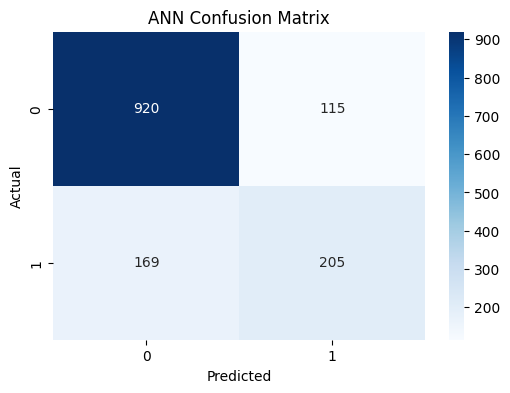

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")

plt.show()

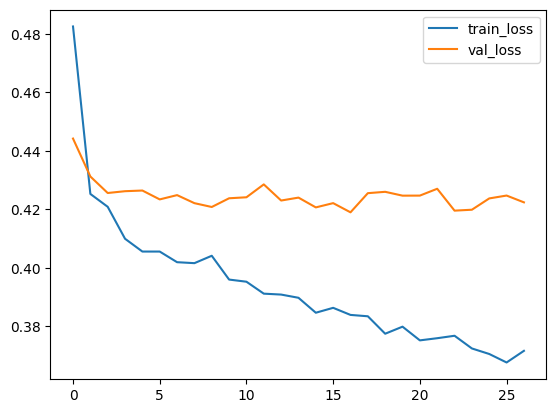

In [46]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')

plt.legend()
plt.show()

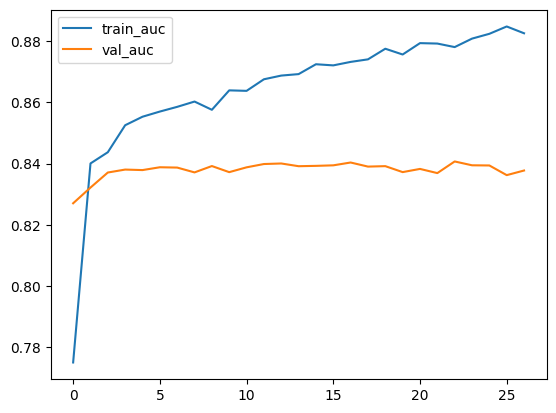

In [47]:
plt.plot(history.history['auc'], label='train_auc')
plt.plot(history.history['val_auc'], label='val_auc')

plt.legend()
plt.show()

In [53]:
import joblib

joblib.dump(preprocessor,
'/content/drive/MyDrive/ML_Projects/CustomerChurn_pred/preprocessor.pkl')

model.save("model.keras")
model.save("/content/drive/MyDrive/ML_Projects/CustomerChurn_pred/model.keras")

In [49]:
print(X_train.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']
